# **Module_3: Fibrosis**

## **Team Members:** Theresa Breckley and Mohamed Elfaki

## **Project Title:**
*(Fill in)*



## **Project Goal:**
This project seeks to... *(what is the purpose of your project -- i.e., describe the question that you seek to answer by analyzing data.)*

## **Disease Background:** 

### **Prevalence and Incidence**

Idiopathic Pulmonary Fibrosis (IPF) is a chronic and progressive interstitial lung disease characterized by irreversible scarring of lung tissue. It is considered relatively rare, with an estimated prevalence of approximately 13–20 cases per 100,000 individuals in the United States. The disease primarily affects older adults, most commonly those over the age of 60, and occurs more frequently in men than in women. Despite its relatively low prevalence, IPF carries a poor prognosis, with a median survival time of only 3–5 years following diagnosis.

### **Risk Factors**

Several risk factors are associated with the development of IPF, although the exact cause remains unknown. Age is the most significant factor, with incidence increasing substantially in older populations. A history of smoking is strongly linked to increased risk, as are environmental and occupational exposures such as metal dust, wood dust, and other airborne pollutants. Genetic predisposition also plays a role, particularly in individuals with family histories of pulmonary fibrosis or mutations affecting surfactant production and telomere maintenance. Additionally, conditions like gastroesophageal reflux disease (GERD) may contribute to repeated lung injury, further increasing risk.

### **Symptoms**

The symptoms of IPF are typically gradual in onset and worsen over time. The most common symptom is progressive shortness of breath, especially during physical activity, which reflects declining lung function. Patients also frequently experience a persistent dry cough, fatigue, and general weakness. As the disease advances, unintended weight loss may occur, and some individuals develop digital clubbing, a condition characterized by the enlargement of the fingertips. These symptoms significantly impact quality of life and become more severe as fibrosis progresses.

### **Standard of Care/Treatment**
    
There is currently no cure for IPF, and treatment focuses on slowing disease progression and managing symptoms. Two primary antifibrotic medications, Pirfenidone and Nintedanib, are commonly prescribed to reduce the rate of lung function decline. Supplemental oxygen therapy is often used to address low blood oxygen levels, while pulmonary rehabilitation programs help improve physical endurance and overall quality of life. For eligible patients, lung transplantation remains the only definitive treatment option. In addition to these interventions, supportive care is essential to manage symptoms and improve patient comfort.

### **Biological Mechanisms (Pathophysiology)**

IPF is driven by repeated micro-injury to the alveolar epithelium, particularly affecting type I and type II pneumocytes, which are essential for gas exchange and surfactant production. Instead of normal tissue repair, the lungs undergo an abnormal healing response characterized by excessive activation of fibroblasts. These cells produce large amounts of collagen and extracellular matrix, leading to thickening and stiffening of lung tissue. This fibrotic remodeling disrupts the alveolar-capillary interface, impairing oxygen diffusion into the bloodstream. As fibrosis progresses, lung compliance decreases, making it more difficult for the lungs to expand, ultimately leading to reduced oxygenation and respiratory failure.

## **Data-Set:**

The dataset used in this project consists of unpublished biomedical imaging data collected by the Peirce-Cottler Lab (Department of Biomedical Engineering) and the Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine. It includes microscopy images of lung tissue samples along with corresponding segmentation masks that isolate regions of interest, such as fibrotic tissue. Each image is associated with a depth value, indicating its position within the tissue, allowing for analysis of spatial variation in fibrosis. The data are organized through structured filenames that encode information about sample region, imaging conditions, and acquisition order, enabling consistent pairing of images, masks, and metadata.

The primary variables analyzed are derived from image processing, including pixel intensity values and the proportion of masked regions, which serve as indicators of tissue structure and fibrosis extent. These values are measured in pixel units, with comparisons made relative across samples. Preprocessing steps include loading image–mask pairs, converting images to numerical arrays, and applying masks to isolate relevant regions. The analysis assumes that masks accurately represent areas of interest and that image quality and depth measurements are consistent. Limitations of the dataset include its relatively small size, lack of clinical metadata, potential variability in imaging conditions, and possible inaccuracies in segmentation, all of which may impact the generalizability and precision of results.

## **Data Analyis:** 

### **Fibrosis at Different Depths**

Counts of pixels by color in each image

MASK_Sk658 Llobe ch010022.jpg
White pixels: 33151
Black pixels: 4161153
0.79% White | Depth: 80 microns

MASK_Sk658 Llobe ch010032.jpg
White pixels: 48667
Black pixels: 4145637
1.16% White | Depth: 500 microns

MASK_Sk658 Llobe ch010171.jpg
White pixels: 57531
Black pixels: 4136773
1.37% White | Depth: 810 microns

MASK_Sk658 Llobe ch010164.jpg
White pixels: 65021
Black pixels: 4129283
1.55% White | Depth: 2200 microns

File not found: C:\Users\15712\OneDrive - University of Virginia\Comp Mod 3\Module-3-Fibrosisb-breckley_elfaki\images\MASK_Sk658 Llobe ch010129.jpg
File not found: C:\Users\15712\OneDrive - University of Virginia\Comp Mod 3\Module-3-Fibrosisb-breckley_elfaki\images\MASK_Sk658 Llobe ch010077.jpg
File not found: C:\Users\15712\OneDrive - University of Virginia\Comp Mod 3\Module-3-Fibrosisb-breckley_elfaki\images\MASK_Sk658 Llobe ch010142.jpg
File not found: C:\Users\15712\OneDrive - University of Virginia\Comp Mod 3\Module-3-Fibros

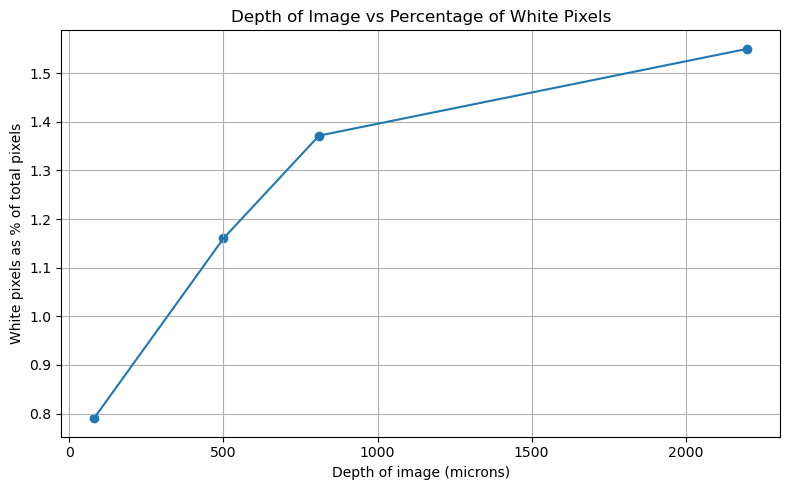

Execution time: 0.0000295000 seconds


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy.interpolate import interp1d
from termcolor import colored

# --------------------------------------------------
# 5 image files and their depths from the CSV
# --------------------------------------------------

image_info = [
    ("C:\\Users\\15712\\OneDrive - University of Virginia\\Comp Mod 3\\Module-3-Fibrosisb-breckley_elfaki\\images\\MASK_Sk658 Llobe ch010022.jpg", 80),
    ("C:\\Users\\15712\\OneDrive - University of Virginia\\Comp Mod 3\\Module-3-Fibrosisb-breckley_elfaki\\images\\MASK_Sk658 Llobe ch010032.jpg", 500),
    ("C:\\Users\\15712\\OneDrive - University of Virginia\\Comp Mod 3\\Module-3-Fibrosisb-breckley_elfaki\\images\\MASK_Sk658 Llobe ch010171.jpg", 810),
    ("C:\\Users\\15712\\OneDrive - University of Virginia\\Comp Mod 3\\Module-3-Fibrosisb-breckley_elfaki\\images\\MASK_Sk658 Llobe ch010164.jpg", 2200),
    ("C:\\Users\\15712\\OneDrive - University of Virginia\\Comp Mod 3\\Module-3-Fibrosisb-breckley_elfaki\\images\\MASK_Sk658 Llobe ch010129.jpg", 3250),
    ("C:\\Users\\15712\\OneDrive - University of Virginia\\Comp Mod 3\\Module-3-Fibrosisb-breckley_elfaki\\images\\MASK_Sk658 Llobe ch010077.jpg", 5900),
    ("C:\\Users\\15712\\OneDrive - University of Virginia\\Comp Mod 3\\Module-3-Fibrosisb-breckley_elfaki\\images\\MASK_Sk658 Llobe ch010142.jpg", 7100),
    ("C:\\Users\\15712\\OneDrive - University of Virginia\\Comp Mod 3\\Module-3-Fibrosisb-breckley_elfaki\\images\\MASK_Sk658 Llobe ch010059.jpg", 7700),
    ("C:\\Users\\15712\\OneDrive - University of Virginia\\Comp Mod 3\\Module-3-Fibrosisb-breckley_elfaki\\images\\MASK_Sk658 Llobe ch010111.jpg", 8600),
    ("C:\\Users\\15712\\OneDrive - University of Virginia\\Comp Mod 3\\Module-3-Fibrosisb-breckley_elfaki\\images\\MASK_Sk658 Llobe ch010135.jpg", 9500),



]

threshold_value = 127
results = []

print("Counts of pixels by color in each image\n")

# --------------------------------------------------
# Process each image one at a time
# --------------------------------------------------

for filepath, depth in image_info:
    path = Path(filepath)

    if not path.exists():
        print(f"File not found: {path}")
        continue

    # Open image and convert to grayscale
    img = Image.open(path).convert("L")
    img_array = np.array(img)

    # Make binary image:
    # pixels > threshold are white, the rest are black
    binary = img_array > threshold_value

    white_count = np.count_nonzero(binary)
    total_pixels = binary.size
    black_count = total_pixels - white_count
    white_percent = 100 * white_count / total_pixels

    results.append({
        "Filename": path.name,
        "Depth (microns)": depth,
        "White pixels": white_count,
        "Black pixels": black_count,
        "White percent": white_percent
    })

    print(f"{path.name}")
    print(f"White pixels: {white_count}")
    print(f"Black pixels: {black_count}")
    print(f"{white_percent:.2f}% White | Depth: {depth} microns\n")

# --------------------------------------------------
# Save results to CSV
# --------------------------------------------------

df = pd.DataFrame(results)
df.to_csv("Percent_White_Pixels.csv", index=False)

print("The .csv file 'Percent_White_Pixels.csv' has been created.")

# --------------------------------------------------
# Plot depth vs percent white
# --------------------------------------------------

depths = df["Depth (microns)"].to_numpy()
white_percents = df["White percent"].to_numpy()

plt.figure(figsize=(8, 5))
plt.scatter(depths, white_percents)
plt.plot(depths, white_percents)
plt.title("Depth of Image vs Percentage of White Pixels")
plt.xlabel("Depth of image (microns)")
plt.ylabel("White pixels as % of total pixels")
plt.grid(True)
plt.tight_layout()
plt.show()

import time 

start_time = time.perf_counter()

end_time = time.perf_counter()
print(f"Execution time: {end_time - start_time:.10f} seconds")

### **Interpolation:**

The interpolated point is at depth 1250.0 microns with white pixel percentage 1.43%.


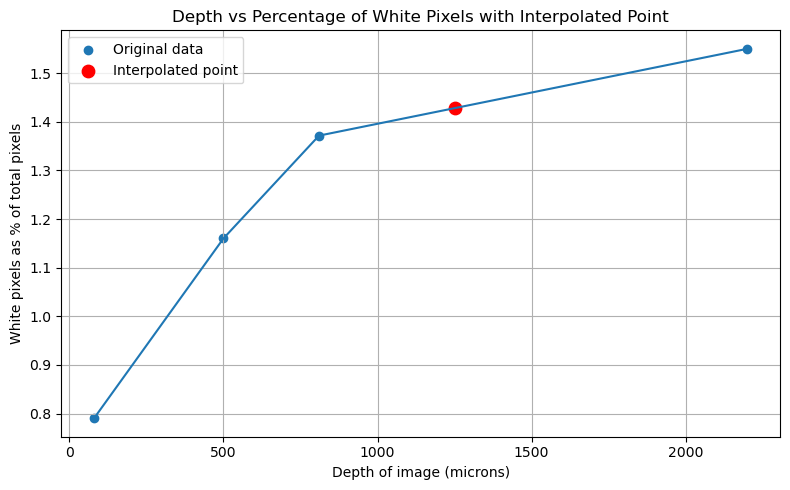

In [3]:
interpolate_depth = float(input("Enter the depth to interpolate (in microns): "))
interpolator = interp1d(depths, white_percents, kind="linear")
interpolated_percent = float(interpolator(interpolate_depth))

print(
    f"The interpolated point is at depth {interpolate_depth} microns "
    f"with white pixel percentage {interpolated_percent:.2f}%."
)

plt.figure(figsize=(8, 5))
plt.scatter(depths, white_percents, label="Original data")
plt.plot(depths, white_percents)
plt.scatter(interpolate_depth, interpolated_percent, color="red", s=80, label="Interpolated point")
plt.title("Depth vs Percentage of White Pixels with Interpolated Point")
plt.xlabel("Depth of image (microns)")
plt.ylabel("White pixels as % of total pixels")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## **Verify and validate your analysis:** 
*Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., by comparing your analysis to a published paper).*

## **Conclusions and Ethical Implications:** 
*Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## **Limitations and Future Work:**
*Describe the limitations of your project. If you had more time to work on this, what would you do to explore further or refine your analysis?*

## **References:**
*You can use any format you like but provide the citations for facts that you referenced in this project notebook.*